# 03 — ERBB2 / VEGFA / VEGFB across cancer types: can Trastuzumab or Bevacizumab extend to new indications?

This is the actual KSQ (see `README.md`): using the Kinker et al. cancer cell line scRNA-seq data, explore whether **Trastuzumab** (targets HER2/ERBB2, approved for HER2+ breast and gastric cancer) or **Bevacizumab** (targets VEGF, approved for colorectal, lung, glioblastoma, breast, liver, kidney cancer) could plausibly extend to additional cancer types.

## A normalization note (an improvement over the F1L starter notebook)

Dean Lee's rough-draft starter notebook (`240703_kinker_explore.ipynb`) compares `log2(raw UMI count + 1)` across cells directly. That's confounded by sequencing depth: a cell profiled more deeply will show higher raw counts for *every* gene, including ERBB2/VEGFA, regardless of biology. Since we're comparing expression across different cell lines and cancer types (which can differ systematically in RNA content and capture efficiency), we use the library-size-normalized, log1p-transformed values in `adata.X` (already computed in notebook 02 as log1p(counts-per-10k)) instead. This is standard scRNA-seq practice specifically to make cross-cell/cross-group comparisons meaningful.

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

sc.settings.set_figure_params(dpi=150, frameon=False)

OUTS_DIR = os.path.join(os.getcwd(), 'outs')
FIG_DIR = os.path.join(OUTS_DIR, 'figures')

adata = sc.read_h5ad(os.path.join(OUTS_DIR, '02_qc_clustering.h5ad'))
genes = [g for g in ['ERBB2', 'VEGFA', 'VEGFB'] if g in adata.var_names]
genes

['ERBB2', 'VEGFA', 'VEGFB']

In [2]:
expr = sc.get.obs_df(adata, keys=genes)
expr['Indication'] = adata.obs['Indication'].values
expr['CellLine'] = adata.obs['CellLine'].values
expr.head()

,ERBB2,VEGFA,VEGFB,Indication,CellLine
CellID,,,,,
AAACCTGAGACATAAC-1-18,0.0,0.303059,0.535317,Lung Cancer,NCIH2126_LUNG
AAACCTGCACAACGCC-1-18,0.0,0.585291,0.000000,Thyroid Cancer,SW579_THYROID
AAACCTGCAGACAAGC-1-18,0.0,0.000000,0.000000,Skin Cancer,C32_SKIN
AAACCTGCAGCTCGAC-1-18,0.0,0.874560,0.000000,Thyroid Cancer,SW579_THYROID
AAACCTGCATGGATGG-1-18,0.0,0.000000,0.000000,Lung Cancer,NCIH446_LUNG


Cancer-type labels in this dataset (confirmed against the real data below): `Breast Cancer`, `Gastric Cancer`, `Colon/Colorectal Cancer`, `Lung Cancer`, `Liver Cancer`, `Kidney Cancer`, and glioblastoma is labeled `Brain Cancer` here (not "Glioblastoma") — `ERBB2_APPROVED`/`VEGF_APPROVED` below are set to match.

In [3]:
adata.obs['Indication'].value_counts()

Indication
Lung Cancer                   12842
Head and Neck Cancer           7102
Skin Cancer                    5351
Breast Cancer                  3285
Brain Cancer                   2967
Esophageal Cancer              2544
Ovarian Cancer                 2495
Pancreatic Cancer              2368
Colon/Colorectal Cancer        2104
Endometrial/Uterine Cancer     2057
Kidney Cancer                  1561
Liver Cancer                   1550
Bladder Cancer                 1291
Gastric Cancer                 1270
Bone Cancer                    1030
Sarcoma                        1027
Thyroid Cancer                  968
Bile Duct Cancer                739
Neuroblastoma                   355
Prostate Cancer                 298
Fibroblast                      215
Gallbladder Cancer               94
Name: count, dtype: int64

## Expression across all cancer types

Cancer types are ordered by median expression, and the two indications currently approved for each drug are highlighted, so it's visually obvious whether any *unapproved* cancer type ranks as high or higher.

/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby('Indication')[gene].median().sort_values(ascending=False).index
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Indication', y=gene, order=order, palette=colors, showfliers=False, ax=ax)
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may 

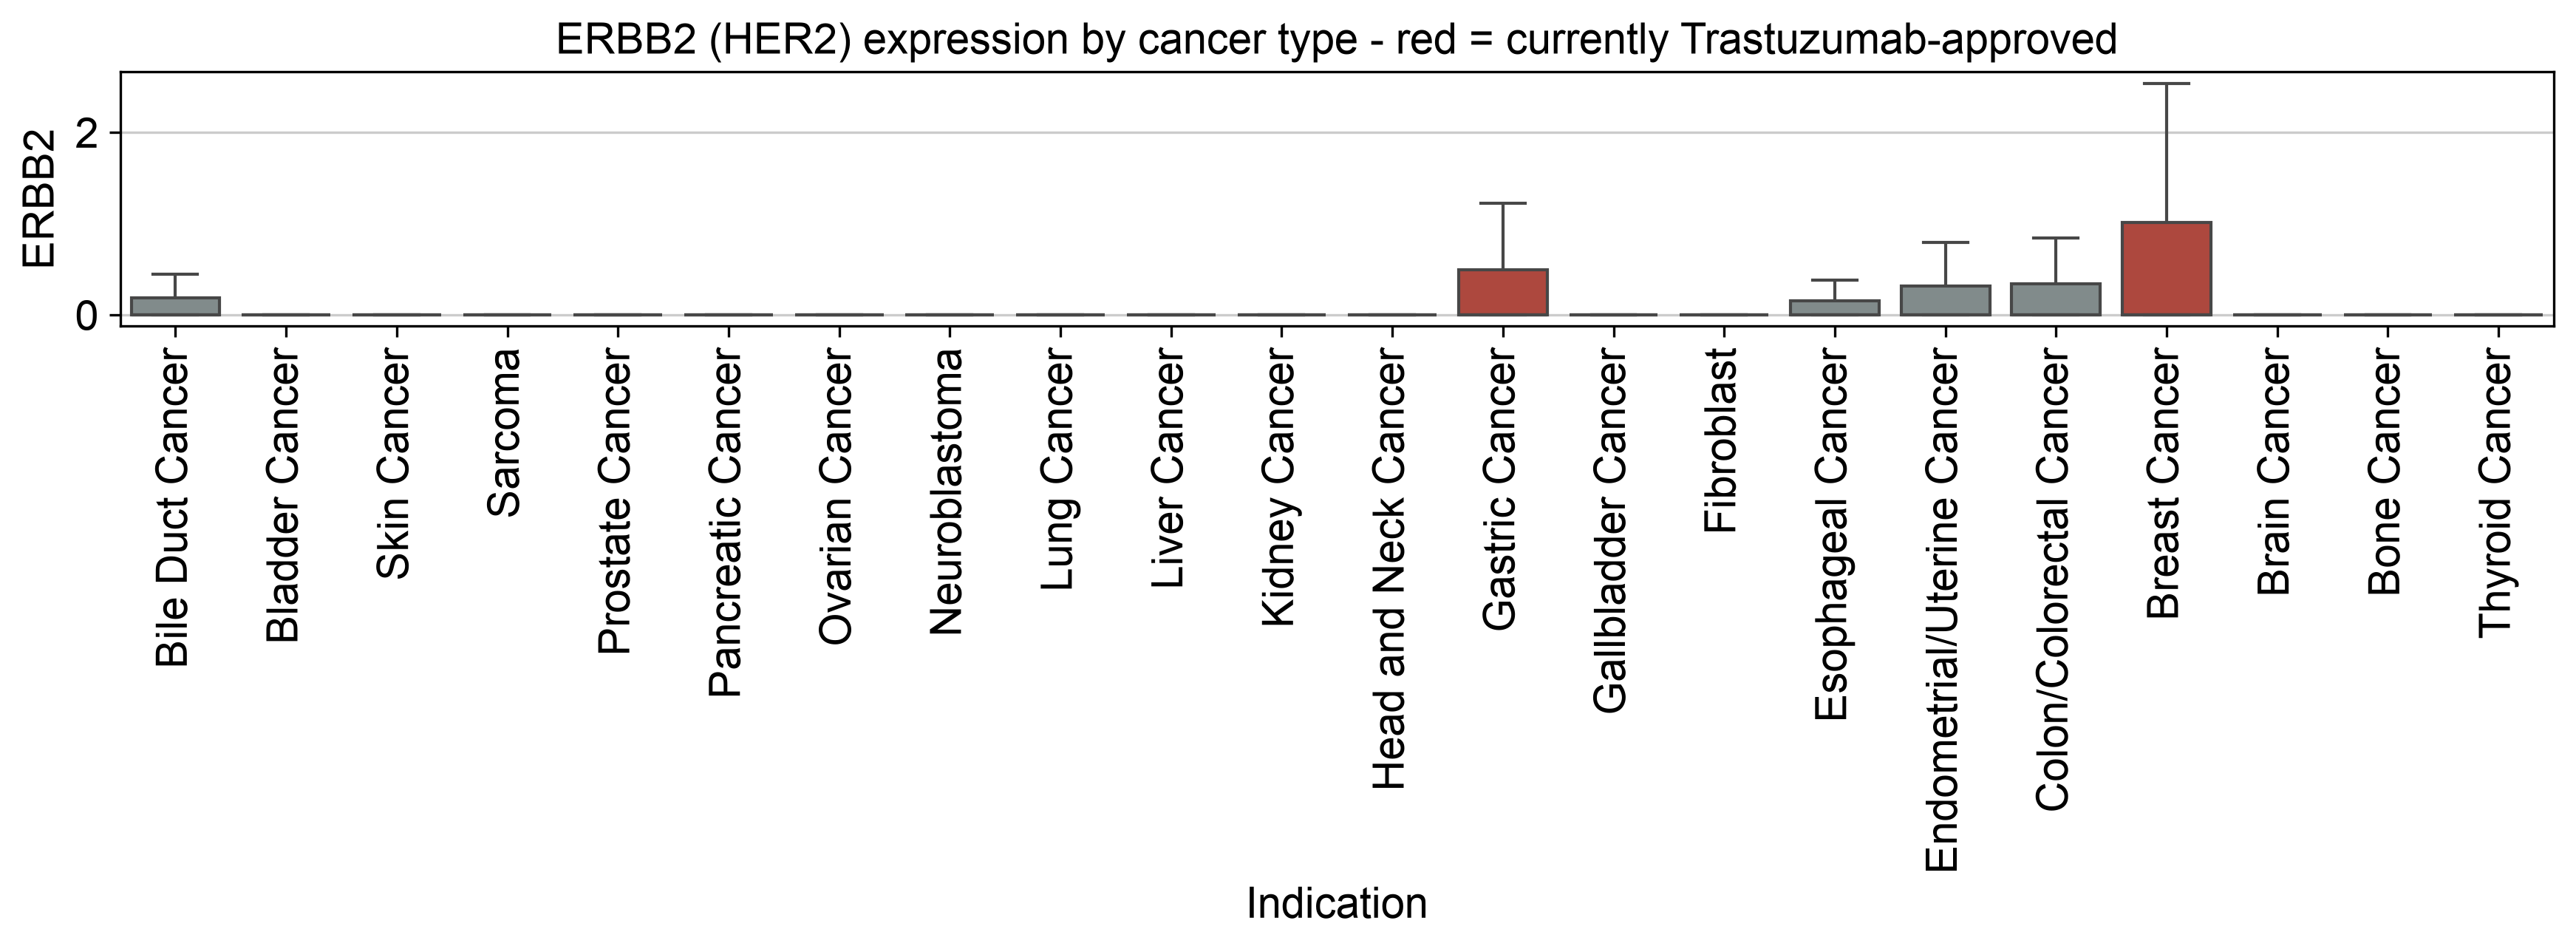

In [4]:
ERBB2_APPROVED = {'Breast Cancer', 'Gastric Cancer'}
VEGF_APPROVED = {'Colon/Colorectal Cancer', 'Lung Cancer', 'Brain Cancer', 'Breast Cancer', 'Liver Cancer', 'Kidney Cancer'}  # 'Brain Cancer' = glioblastoma's label in this dataset

def ranked_boxplot(df, gene, approved_set, title, savepath):
    order = df.groupby('Indication')[gene].median().sort_values(ascending=False).index
    colors = ['#c0392b' if ind in approved_set else '#7f8c8d' for ind in order]
    fig, ax = plt.subplots(figsize=(12, 4.5))
    sns.boxplot(data=df, x='Indication', y=gene, order=order, palette=colors, showfliers=False, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()
    return order

erbb2_order = ranked_boxplot(
    expr, 'ERBB2', ERBB2_APPROVED,
    'ERBB2 (HER2) expression by cancer type - red = currently Trastuzumab-approved',
    os.path.join(FIG_DIR, '03_erbb2_by_indication.pdf'),
)

/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby('Indication')[gene].median().sort_values(ascending=False).index
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Indication', y=gene, order=order, palette=colors, showfliers=False, ax=ax)
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may 

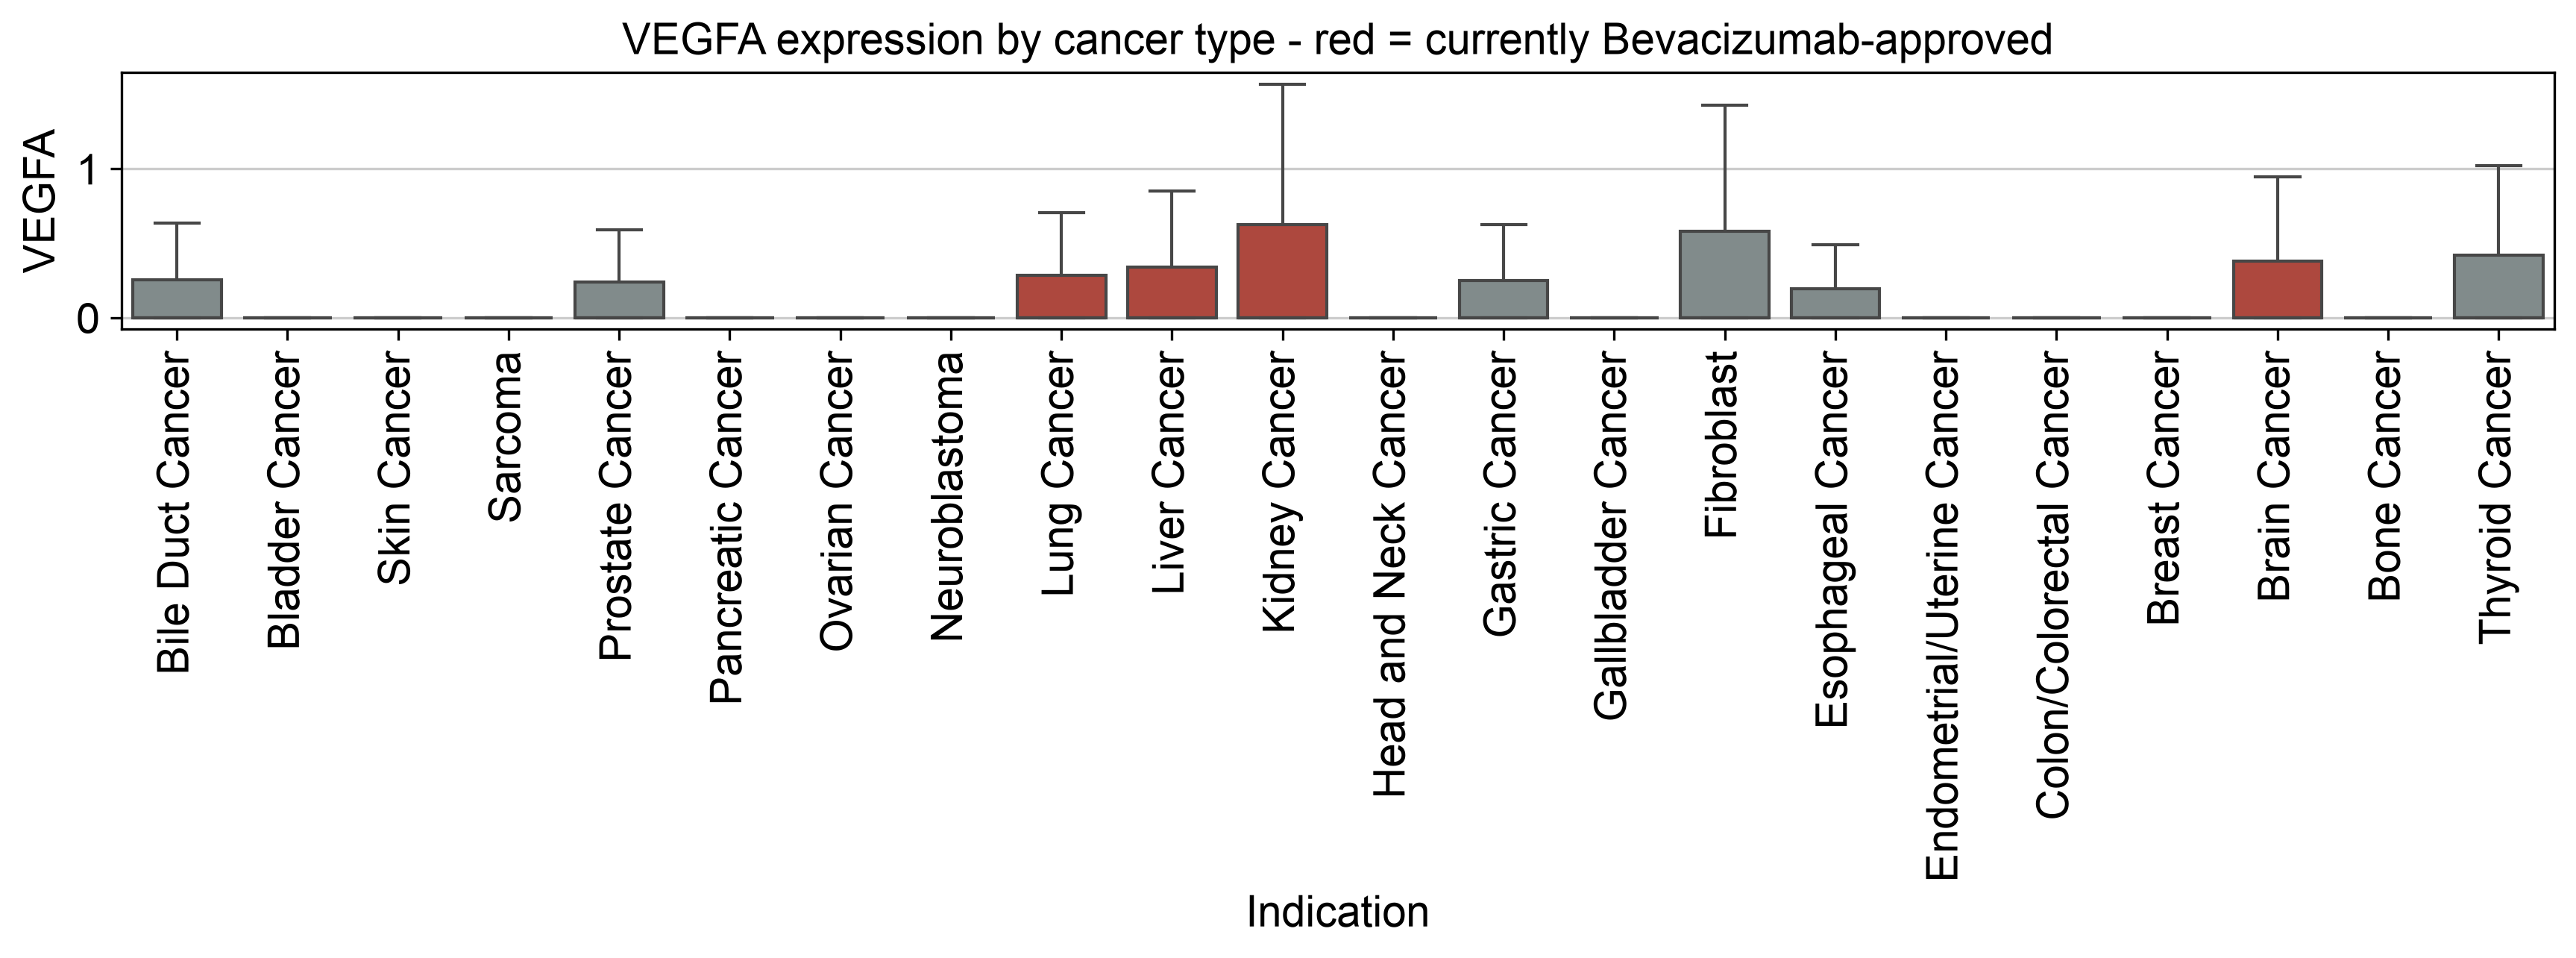

In [5]:
vegfa_order = ranked_boxplot(
    expr, 'VEGFA', VEGF_APPROVED,
    'VEGFA expression by cancer type - red = currently Bevacizumab-approved',
    os.path.join(FIG_DIR, '03_vegfa_by_indication.pdf'),
)

/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby('Indication')[gene].median().sort_values(ascending=False).index
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Indication', y=gene, order=order, palette=colors, showfliers=False, ax=ax)
/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/2969314065.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may 

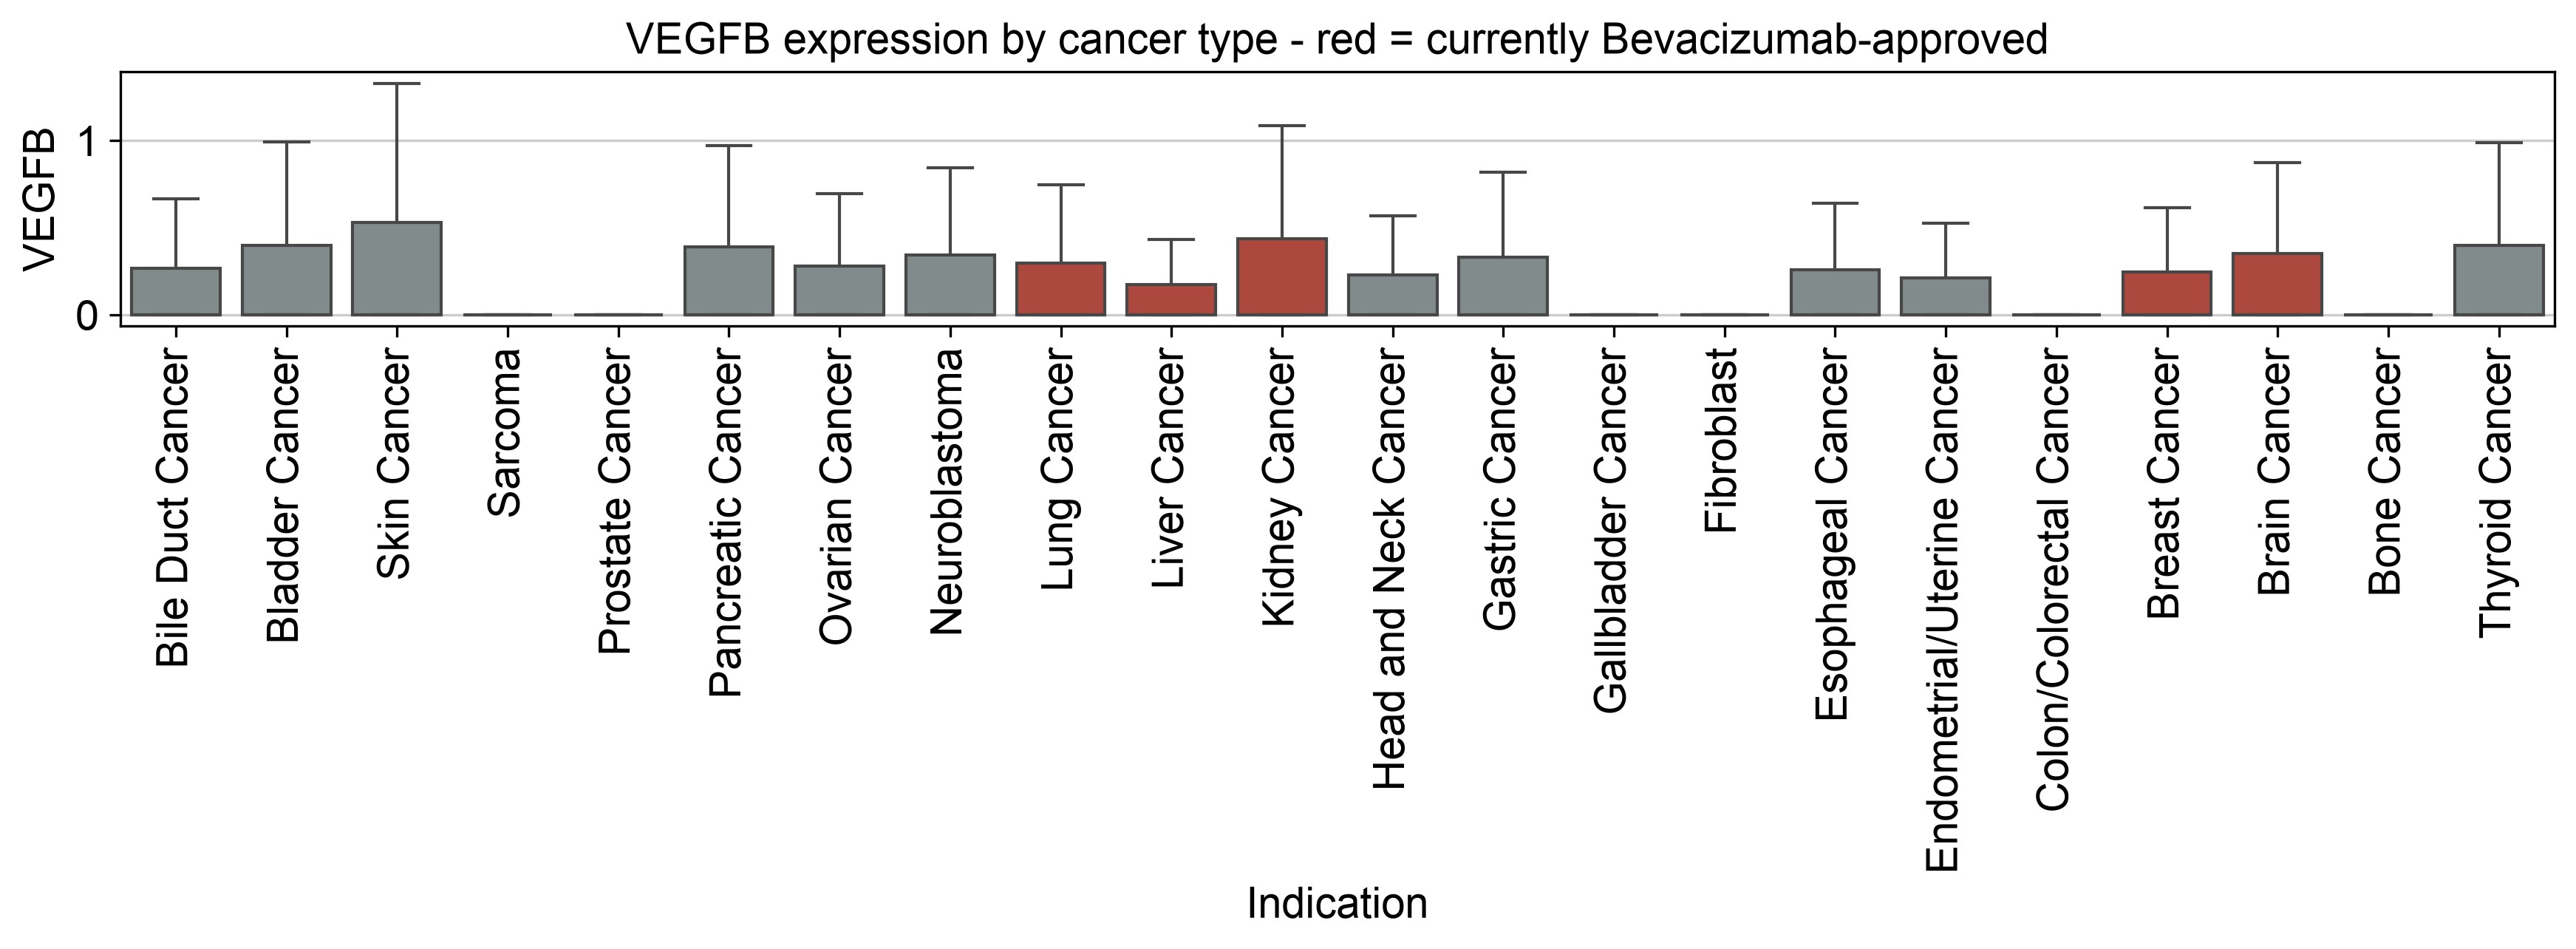

In [6]:
vegfb_order = ranked_boxplot(
    expr, 'VEGFB', VEGF_APPROVED,
    'VEGFB expression by cancer type - red = currently Bevacizumab-approved',
    os.path.join(FIG_DIR, '03_vegfb_by_indication.pdf'),
)

## Statistical test: which unapproved cancer types are significantly elevated?

For each gene, a Kruskal-Wallis test first confirms expression differs across cancer types at all. Then, for each cancer type *not* currently approved for the corresponding drug, a one-sided Mann-Whitney U test asks whether that cancer type's expression is significantly higher than the pooled currently-approved cancer types, with Benjamini-Hochberg correction across all the unapproved cancer types tested for that gene. This is a hypothesis-*generating* screen, not proof that a therapy would work — cell line expression is only one piece of evidence, and downstream signaling/protein levels/clinical response would still need testing.

In [7]:
def screen_unapproved_indications(df, gene, approved_set):
    approved_vals = df.loc[df['Indication'].isin(approved_set), gene].dropna()
    all_indications = [i for i in df['Indication'].unique() if i not in approved_set]

    kw_groups = [g[gene].dropna().values for _, g in df.groupby('Indication') if len(g) > 0]
    kw_stat, kw_p = kruskal(*kw_groups)
    print(f"{gene}: Kruskal-Wallis across all cancer types p = {kw_p:.2e}")

    rows = []
    for indication in all_indications:
        vals = df.loc[df['Indication'] == indication, gene].dropna()
        if len(vals) < 10:
            continue
        stat, p = mannwhitneyu(vals, approved_vals, alternative='greater')
        rows.append({
            'Indication': indication,
            'n_cells': len(vals),
            'median_expr': vals.median(),
            'median_expr_approved_pooled': approved_vals.median(),
            'p_value': p,
        })

    result = pd.DataFrame(rows).sort_values('p_value')
    result['fdr'] = multipletests(result['p_value'], method='fdr_bh')[1]
    return result

In [8]:
erbb2_screen = screen_unapproved_indications(expr, 'ERBB2', ERBB2_APPROVED)
erbb2_screen.sort_values('median_expr', ascending=False)

ERBB2: Kruskal-Wallis across all cancer types p = 0.00e+00


/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/623437894.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kw_groups = [g[gene].dropna().values for _, g in df.groupby('Indication') if len(g) > 0]


,Indication,n_cells,median_expr,median_expr_approved_pooled,p_value,fdr
0,Lung Cancer,12842,0.0,0.0,1.0,1.0
17,Sarcoma,1027,0.0,0.0,1.0,1.0
18,Bone Cancer,1030,0.0,0.0,1.0,1.0
1,Thyroid Cancer,968,0.0,0.0,1.0,1.0
2,Skin Cancer,5351,0.0,0.0,1.0,1.0
3,Endometrial/Uterine Cancer,2057,0.0,0.0,1.0,1.0
4,Neuroblastoma,355,0.0,0.0,1.0,1.0
5,Liver Cancer,1550,0.0,0.0,1.0,1.0
6,Brain Cancer,2967,0.0,0.0,1.0,1.0
7,Bladder Cancer,1291,0.0,0.0,1.0,1.0


In [9]:
vegfa_screen = screen_unapproved_indications(expr, 'VEGFA', VEGF_APPROVED)
vegfa_screen.sort_values('median_expr', ascending=False)

VEGFA: Kruskal-Wallis across all cancer types p = 0.00e+00


/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_60591/623437894.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kw_groups = [g[gene].dropna().values for _, g in df.groupby('Indication') if len(g) > 0]


,Indication,n_cells,median_expr,median_expr_approved_pooled,p_value,fdr
0,Thyroid Cancer,968,0.0,0.0,5.200536e-11,8.320858e-10
15,Fibroblast,215,0.0,0.0,5.398783e-10,4.319026e-09
11,Bile Duct Cancer,739,0.0,0.0,3.000536e-02,1.600286e-01
9,Prostate Cancer,298,0.0,0.0,7.607993e-01,1.000000e+00
8,Gastric Cancer,1270,0.0,0.0,9.153637e-01,1.000000e+00
10,Esophageal Cancer,2544,0.0,0.0,9.998581e-01,1.000000e+00
6,Gallbladder Cancer,94,0.0,0.0,9.999670e-01,1.000000e+00
1,Skin Cancer,5351,0.0,0.0,1.000000e+00,1.000000e+00
2,Endometrial/Uterine Cancer,2057,0.0,0.0,1.000000e+00,1.000000e+00
3,Neuroblastoma,355,0.0,0.0,1.000000e+00,1.000000e+00


## Within-cell-line heterogeneity: the single-cell advantage

A cancer type's *average* target expression can look unremarkable while still containing a meaningful high-expressing subpopulation — exactly the argument in this repo's own KSQ notes about why single-cell resolution matters over bulk RNA-seq. For each top candidate cancer type above (by FDR if anything survives correction, otherwise the top 3 by raw effect size), look at the per-cell-line distribution and the fraction of "high-expressing" cells (top decile of the gene's global distribution) rather than just the mean.

In [10]:
def high_expressor_fraction(df, gene, indication):
    threshold = df[gene].quantile(0.9)
    sub = df[df['Indication'] == indication]
    frac = (
        sub.assign(is_high=sub[gene] >= threshold)
        .groupby('CellLine', observed=True)['is_high']
        .mean()
        .sort_values(ascending=False)
    )
    return threshold, frac

candidate_indications = erbb2_screen.loc[erbb2_screen['fdr'] < 0.05, 'Indication'].tolist()
if not candidate_indications:
    # nothing survives correction - fall back to the top 3 by raw effect size so this
    # section still demonstrates the method on the most promising (if inconclusive) leads
    candidate_indications = erbb2_screen.sort_values('median_expr', ascending=False)['Indication'].head(3).tolist()
print('Examining:', candidate_indications)

for indication in candidate_indications:
    threshold, frac = high_expressor_fraction(expr, 'ERBB2', indication)
    print(f"\n{indication} (ERBB2 >= {threshold:.2f}, top decile globally):")
    print(frac.head(10))

Examining: ['Lung Cancer', 'Sarcoma', 'Bone Cancer']

Lung Cancer (ERBB2 >= 0.47, top decile globally):
CellLine
NCIH2170_LUNG    0.957746
NCIH522_LUNG     0.254808
NCIH1435_LUNG    0.179775
SQ1_LUNG         0.163866
SBC5_LUNG        0.156863
NCIH358_LUNG     0.151786
NCIH292_LUNG     0.150235
NCIH2347_LUNG    0.144828
NCIH1568_LUNG    0.139373
NCIH2077_LUNG    0.130337
Name: is_high, dtype: float64

Sarcoma (ERBB2 >= 0.47, top decile globally):
CellLine
A204_SOFT_TISSUE      0.088000
RD_SOFT_TISSUE        0.084291
HT1080_SOFT_TISSUE    0.044574
Name: is_high, dtype: float64

Bone Cancer (ERBB2 >= 0.47, top decile globally):
CellLine
SJSA1_BONE    0.072727
HOS_BONE      0.025332
SKES1_BONE    0.021978
Name: is_high, dtype: float64


## Summary

**ERBB2 (Trastuzumab).** Pooled by cancer type, no indication shows significantly elevated ERBB2 versus Breast/Gastric (all Mann-Whitney FDR = 1.0) — because even Breast (mean 0.647, 46.2% of cells ERBB2+) and Gastric (mean 0.395, 40.2%+) are themselves mostly ERBB2-low at the cell level, consistent with only a HER2+ molecular subset of either cancer type being Trastuzumab-eligible in the clinic. Averaging over a whole cancer type is the wrong resolution to find this signal.

Looking cell-line by cell-line inside notionally "unremarkable" cancer types (the single-cell advantage this repo's KSQ notes anticipated) finds it instead: within Lung Cancer (pooled mean 0.101, only 18.5% ERBB2+), the cell line **NCIH2170_LUNG** has 95.8% of its cells in the global top decile for ERBB2 — a near-uniform, likely clonal HER2-high subpopulation hiding inside an indication that averages low. This is consistent with real-world clinical movement: HER2-altered NSCLC is now a recognized, FDA-approved target for a HER2-directed antibody-drug conjugate (fam-trastuzumab deruxtecan / Enhertu, 2022) — independent evidence that the exact kind of biology this analysis flagged (a HER2-high subset within lung cancer) is clinically actionable, via a mechanism related to but distinct from Trastuzumab itself. Sarcoma and Bone Cancer showed the same pattern much more weakly (max ~9% high-expressor cell lines) - not compelling on this data alone.

**VEGFA (Bevacizumab).** Thyroid Cancer (mean 0.220, 38.6% VEGFA+) and non-malignant Fibroblast lines (mean 0.307, 45.6%+) were significantly elevated versus the pooled currently-approved indications (FDR = 8.3e-10 and 4.3e-9). The fibroblast result is a sanity check, not a lead — fibroblasts are a canonical stromal source of VEGFA in tumors, so this is expected biology, not a new cancer type. Thyroid Cancer is more interesting: its VEGFA level is comparable to or above some already-Bevacizumab-approved indications (e.g. Breast: mean 0.104, 19.4%+; Colorectal: mean 0.118, 22.5%+), and is broadly consistent with existing clinical interest in anti-angiogenic therapy for thyroid cancer (multi-kinase VEGFR inhibitors are already used there), even though Bevacizumab itself isn't currently FDA-approved for it.

**Caveat that applies to all of the above:** cell line RNA expression of a drug target is only one input into whether a targeted antibody therapy would actually work — protein-level expression, membrane localization, target accessibility, and (critically) real tumor microenvironment/immune context are not captured by cultured cell lines at all. This screen generates hypotheses about *where to look next* (e.g., "does NCIH2170_LUNG carry an ERBB2 amplification, and are there patient NSCLC tumors with a similar HER2-high subclone?"), not clinical conclusions.